Yashasvi Goswami | 57 | MSC | Network Science

In [35]:
import networkx as nx
import matplotlib.pyplot as plt
import csv

Q1. Degree Centrality Analysis on Social Network Datasets
Using Zachary's Karate Club graph and the Dolphin Social Network dataset, calculate and compare
the degree centrality of all nodes without using the NetworkX built-in function
nx.degree_centrality().
Perform the following tasks for both datasets:
1. Load the Zachary's Karate Club graph and the Dolphin Social Network dataset.
2. Determine the total number of nodes N and the degree k_i of each node.
3. Calculate the degree centrality of every node manually using the formula:
CD(i) =ki(N−1)
where:
● k_i is the degree of node i.
● N is the total number of nodes.
4. Implement the calculation using Python loops or dictionary operations without calling:
nx.degree_centrality(G)
5. Display the degree and calculated degree centrality value for every node.
6. Identify and display the top 5 nodes with the highest degree centrality.
7. Visualize both networks, where the node size is proportional to the manually calculated degree
centrality.
8. Compare the top 5 most connected nodes in the Zachary's Karate Club and Dolphin social
networks.
9. Verify the manually calculated results by comparing them with NetworkX's
nx.degree_centrality() function only after completing the from-scratch implementation.
10. Briefly explain what a high degree centrality value represents in each social network.

In [36]:
karate = nx.karate_club_graph()
dolphins = nx.read_gml("/content/dolphins.gml")

print("Karate nodes:", len(karate))
print("Dolphin nodes:", len(dolphins))

Karate nodes: 34
Dolphin nodes: 62


In [37]:
def degree_centrality(G):
    N = len(G)
    result = {}

    for node in G.nodes():
        k = len(list(G.neighbors(node)))
        centrality = k / (N - 1)
        result[node] = (k, centrality)
    return result


karate_result = degree_centrality(karate)
dolphin_result = degree_centrality(dolphins)

In [38]:
def display_result(G, result, name):

    print("\n" + name)
    print("Number of nodes:", len(G))
    print("Node\tDegree\tCentrality")

    for node, (degree, centrality) in result.items():
        print(node, "\t", degree, "\t", round(centrality, 4))

display_result(karate, karate_result, "KARATE CLUB")
display_result(dolphins, dolphin_result, "DOLPHIN NETWORK")


KARATE CLUB
Number of nodes: 34
Node	Degree	Centrality
0 	 16 	 0.4848
1 	 9 	 0.2727
2 	 10 	 0.303
3 	 6 	 0.1818
4 	 3 	 0.0909
5 	 4 	 0.1212
6 	 4 	 0.1212
7 	 4 	 0.1212
8 	 5 	 0.1515
9 	 2 	 0.0606
10 	 3 	 0.0909
11 	 1 	 0.0303
12 	 2 	 0.0606
13 	 5 	 0.1515
14 	 2 	 0.0606
15 	 2 	 0.0606
16 	 2 	 0.0606
17 	 2 	 0.0606
18 	 2 	 0.0606
19 	 3 	 0.0909
20 	 2 	 0.0606
21 	 2 	 0.0606
22 	 2 	 0.0606
23 	 5 	 0.1515
24 	 3 	 0.0909
25 	 3 	 0.0909
26 	 2 	 0.0606
27 	 4 	 0.1212
28 	 3 	 0.0909
29 	 4 	 0.1212
30 	 4 	 0.1212
31 	 6 	 0.1818
32 	 12 	 0.3636
33 	 17 	 0.5152

DOLPHIN NETWORK
Number of nodes: 62
Node	Degree	Centrality
Beak 	 6 	 0.0984
Beescratch 	 8 	 0.1311
Bumper 	 4 	 0.0656
CCL 	 3 	 0.0492
Cross 	 1 	 0.0164
DN16 	 4 	 0.0656
DN21 	 6 	 0.0984
DN63 	 5 	 0.082
Double 	 6 	 0.0984
Feather 	 7 	 0.1148
Fish 	 5 	 0.082
Five 	 1 	 0.0164
Fork 	 1 	 0.0164
Gallatin 	 8 	 0.1311
Grin 	 12 	 0.1967
Haecksel 	 7 	 0.1148
Hook 	 6 	 0.0984
Jet 	 9 	 0.1475
Jona

In [39]:
def top_five(result):

    top = sorted(result.items(),key=lambda x: x[1][0],reverse=True)
    return top[:5]


print("\nTop 5 - Karate Club")

for node, (degree, centrality) in top_five(karate_result):
    print(node, "Degree =", degree,"Centrality =", round(centrality, 4))


print("\nTop 5 - Dolphin Network")

for node, (degree, centrality) in top_five(dolphin_result):
    print(node, "Degree =", degree,"Centrality =", round(centrality, 4))


Top 5 - Karate Club
33 Degree = 17 Centrality = 0.5152
0 Degree = 16 Centrality = 0.4848
32 Degree = 12 Centrality = 0.3636
2 Degree = 10 Centrality = 0.303
1 Degree = 9 Centrality = 0.2727

Top 5 - Dolphin Network
Grin Degree = 12 Centrality = 0.1967
SN4 Degree = 11 Centrality = 0.1803
Topless Degree = 11 Centrality = 0.1803
Scabs Degree = 10 Centrality = 0.1639
Trigger Degree = 10 Centrality = 0.1639


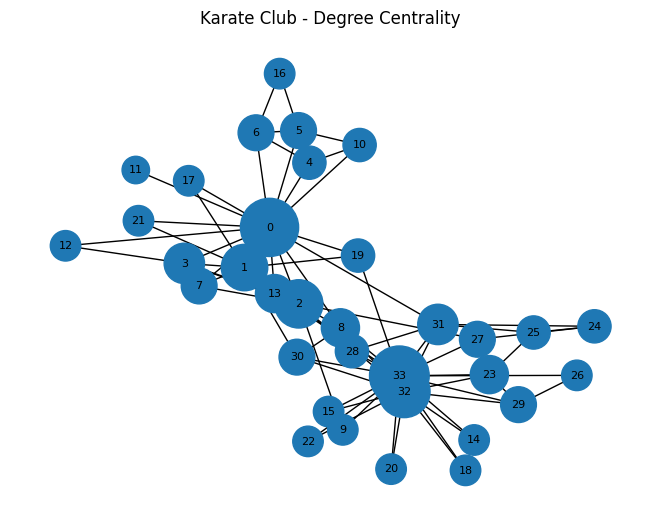

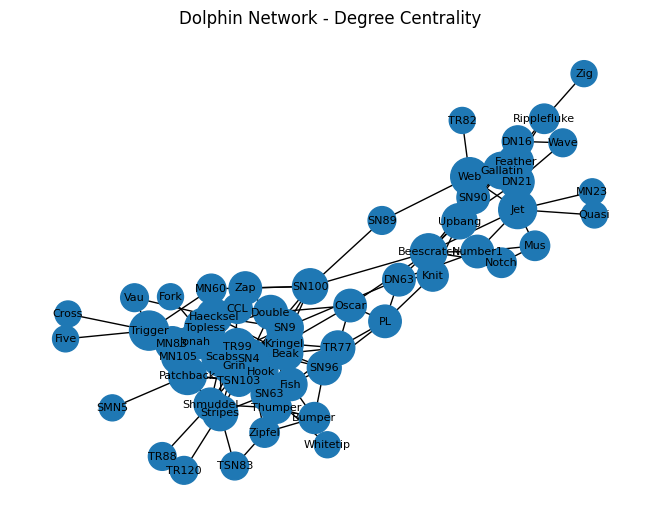

In [40]:
def draw_network(G, result, title):

    pos = nx.spring_layout(G, seed=42)
    sizes = []

    for node in G.nodes():
        centrality = result[node][1]
        sizes.append(300 + centrality * 3000)

    nx.draw(G,pos,node_size=sizes,with_labels=True,font_size=8)
    plt.title(title)
    plt.show()


draw_network(karate,karate_result,"Karate Club - Degree Centrality")

draw_network(dolphins,dolphin_result,"Dolphin Network - Degree Centrality")


In [41]:
print("VERIFICATION")

def verify(G, manual_result, name):

    built_in = nx.degree_centrality(G)
    correct = True

    for node in G.nodes():

        manual = manual_result[node][1]
        if abs(manual - built_in[node]) > 0.000001:
            correct = False
            print(node, "Mismatch")

    if correct:
        print(name, ": All manual values are correct!")

verify(karate, karate_result, "Karate Club")
verify(dolphins, dolphin_result, "Dolphin Network")

VERIFICATION
Karate Club : All manual values are correct!
Dolphin Network : All manual values are correct!


A person with high degree centrality is well-connected to many people and can easily interact with or spread information to others in the network.

Q2. Closeness Centrality Analysis: Using Zachary's Karate Club and the Dolphin Social Network
datasets, analyze and compare the closeness centrality of individuals without using
nx.closeness_centrality() or NetworkX shortest-path functions.
1. Manual Implementation: For every node, implement Breadth-First Search (BFS) from scratch
to calculate the shortest-path distance to all other nodes and compute closeness centrality using:
C
C
(i) =
N−1
j≠i
∑ d(i, j)

2. Ranking Analysis: Calculate and display the closeness centrality of all nodes and identify the
top 5 most centrally positioned nodes in each network.
3. Visual Analysis: Visualize both networks with node sizes proportional to the manually calculated
closeness centrality and identify the structurally central individuals.
4. Comparative Challenge: Compare the node with the highest closeness centrality against the
node with the highest degree centrality in each dataset. Determine whether the same individual is
identified as most important and justify your answer using network structure.
5. Verification and Interpretation: Verify the manually calculated results using
nx.closeness_centrality() only after completing the implementation. Compare the top 5 rankings
across both networks and explain why individuals with high closeness centrality can spread
information efficiently.

In [42]:
def bfs_distances(G, start):

    distance = {start: 0}
    queue = [start]

    while queue:
        node = queue.pop(0)

        for neighbour in G.neighbors(node):
            if neighbour not in distance:
                distance[neighbour] = distance[node] + 1
                queue.append(neighbour)

    return distance

In [43]:
def manual_closeness(G):

    N = len(G)
    result = {}

    for node in G.nodes():
        distances = bfs_distances(G, node)
        total_distance = sum(distances.values())
        result[node] = (N - 1) / total_distance
    return result


karate_closeness = manual_closeness(karate)
dolphin_closeness = manual_closeness(dolphins)

In [44]:
def display_result(result, name):

    print("\n" + name)
    print("Node\tCloseness")

    for node, value in result.items():
        print(node, "\t", round(value, 4))

display_result(karate_closeness, "KARATE CLUB")
display_result(dolphin_closeness, "DOLPHIN NETWORK")


KARATE CLUB
Node	Closeness
0 	 0.569
1 	 0.4853
2 	 0.5593
3 	 0.4648
4 	 0.3793
5 	 0.3837
6 	 0.3837
7 	 0.44
8 	 0.5156
9 	 0.4342
10 	 0.3793
11 	 0.3667
12 	 0.3708
13 	 0.5156
14 	 0.3708
15 	 0.3708
16 	 0.2845
17 	 0.375
18 	 0.3708
19 	 0.5
20 	 0.3708
21 	 0.375
22 	 0.3708
23 	 0.3929
24 	 0.375
25 	 0.375
26 	 0.3626
27 	 0.4583
28 	 0.4521
29 	 0.3837
30 	 0.4583
31 	 0.541
32 	 0.5156
33 	 0.55

DOLPHIN NETWORK
Node	Closeness
Beak 	 0.3466
Beescratch 	 0.372
Bumper 	 0.2824
CCL 	 0.3081
Cross 	 0.249
DN16 	 0.2383
DN21 	 0.2675
DN63 	 0.3653
Double 	 0.3631
Feather 	 0.2521
Fish 	 0.3128
Five 	 0.249
Fork 	 0.2687
Gallatin 	 0.2711
Grin 	 0.3765
Haecksel 	 0.3389
Hook 	 0.3297
Jet 	 0.3096
Jonah 	 0.337
Knit 	 0.3161
Kringel 	 0.391
MN105 	 0.3333
MN23 	 0.2374
MN60 	 0.3333
MN83 	 0.3128
Mus 	 0.2552
Notch 	 0.2773
Number1 	 0.3161
Oscar 	 0.3653
Patchback 	 0.3228
PL 	 0.3228
Quasi 	 0.2374
Ripplefluke 	 0.2163
Scabs 	 0.3653
Shmuddel 	 0.3161
SMN5 	 0.245
SN100 	 0.41

In [45]:
def top_five(result):
    return sorted(result.items(),key=lambda x: x[1],reverse=True)[:5]

print("\nTop 5 - Karate Club")
for node, value in top_five(karate_closeness):
    print(node, "->", round(value, 4))

print("\nTop 5 - Dolphin Network")
for node, value in top_five(dolphin_closeness):
    print(node, "->", round(value, 4))


Top 5 - Karate Club
0 -> 0.569
2 -> 0.5593
33 -> 0.55
31 -> 0.541
8 -> 0.5156

Top 5 - Dolphin Network
SN100 -> 0.4178
SN9 -> 0.404
SN4 -> 0.3987
Kringel -> 0.391
Grin -> 0.3765


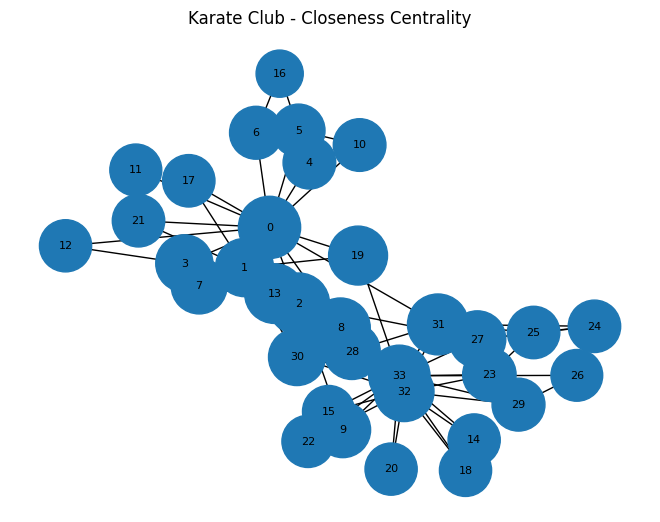

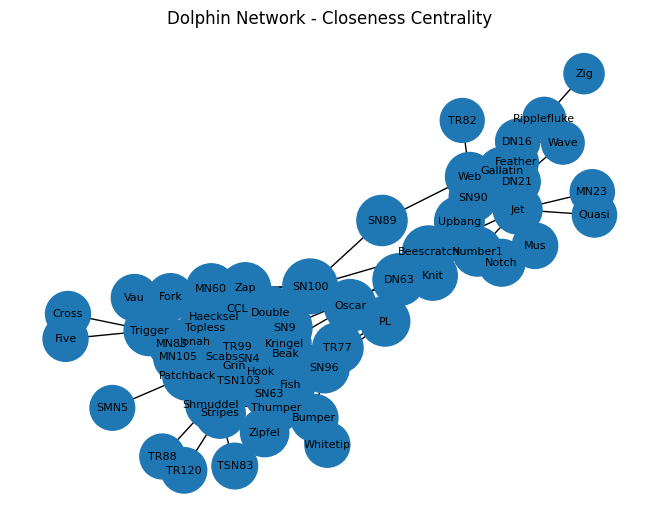

In [46]:
def draw_network(G, result, title):
    pos = nx.spring_layout(G, seed=42)
    sizes = []

    for node in G.nodes():
        sizes.append(300 + result[node] * 3000)

    nx.draw(G,pos,node_size=sizes,with_labels=True,font_size=8)
    plt.title(title)
    plt.show()


draw_network(karate,karate_closeness,"Karate Club - Closeness Centrality")

draw_network(dolphins,dolphin_closeness,"Dolphin Network - Closeness Centrality")

In [47]:
def highest_degree(G):
    return max(G.nodes(), key=lambda x: len(list(G.neighbors(x))))


def highest_closeness(result):
    return max(result, key=result.get)


print("\nComparison")

print("Karate:")
print("Highest Degree Node   :", highest_degree(karate))
print("Highest Closeness Node:", highest_closeness(karate_closeness))

print("\nDolphin:")
print("Highest Degree Node   :", highest_degree(dolphins))
print("Highest Closeness Node:", highest_closeness(dolphin_closeness))


Comparison
Karate:
Highest Degree Node   : 33
Highest Closeness Node: 0

Dolphin:
Highest Degree Node   : Grin
Highest Closeness Node: SN100


In both networks, the most connected individual is not the most centrally positioned. This shows that degree measures direct connections, while closeness measures a node's position in the overall network structure.

In [48]:
print("VERIFICATION")

def verify(G, manual_result, name):
    nx_result = nx.closeness_centrality(G)
    correct = True

    for node in G.nodes():
        if abs(manual_result[node] - nx_result[node]) > 0.000001:
            correct = False
            print(node, "Mismatch")

    if correct:
        print(name, ": All manual values are correct!")

verify(karate, karate_closeness, "Karate Club")
verify(dolphins, dolphin_closeness, "Dolphin Network")

VERIFICATION
Karate Club : All manual values are correct!
Dolphin Network : All manual values are correct!


A high closeness value means the node has shorter average distances to other nodes. Therefore, information can travel from it to the rest of the network using fewer intermediate nodes, making communication more efficient.

Q3: Consider an Airline Travel Reachability Network where cities are represented as nodes and a
directed edge A→B indicates that city B can be reached from city A within a specified travel-time
threshold. The network is asymmetric, meaning A→B does not necessarily imply B→A. Using Python
and NetworkX, perform the following tasks:
1. Construct the Network: Load the airline travel dataset, create a directed graph, and determine
the number of nodes and edges.
2. Calculate Centrality Measures: For each city, calculate the in-degree, out-degree, in-degree
centrality, out-degree centrality, and closeness centrality. Implement degree centrality manually
using formula

3. Implement Closeness from Scratch: Use Breadth-First Search (BFS) to calculate shortest-path
distances and closeness centrality without using nx.closeness_centrality(), nx.shortest_path(), or
nx.shortest_path_length().
4. Analyze and Compare: Identify the top 10 cities based on in-degree centrality, out-degree
centrality, and closeness centrality. Analyze whether a city with the highest number of direct
destinations necessarily has the highest closeness centrality, and identify cities whose rankings
differ significantly.
5. Network Failure Analysis: Suppose a major airport is temporarily closed due to severe weather
or an emergency. Remove that airport from the airline network and analyze how the closure
affects the ability of passengers to travel between cities, the overall travel efficiency, and the
connectivity of the remaining network. Based on your results, identify whether the closed airport
was important because it had many direct connections or because it was strategically positioned
to reach other cities efficiently. Discuss how this analysis can help in transportation planning and
emergency management.

In [49]:
import networkx as nx

G = nx.DiGraph()

with open("reachability.csv", "r") as file:
    print(file.readline())
    next(file)

    for line in file:
        data = line.strip().split(",")

        source = data[0]
        target = data[1]

        G.add_edge(source, target)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

"node_id","name","metro_pop","latitude","longitude"

Nodes: 892
Edges: 455


In [50]:
N = len(G)

in_centrality = {}
out_centrality = {}

for node in G:
    in_degree = len(list(G.predecessors(node)))
    out_degree = len(list(G.successors(node)))

    in_centrality[node] = in_degree / (N - 1)
    out_centrality[node] = out_degree / (N - 1)

In [51]:
def bfs(G, start):

    distance = {start: 0}
    queue = [start]

    while queue:
        node = queue.pop(0)

        for neighbour in G.successors(node):

            if neighbour not in distance:
                distance[neighbour] = distance[node] + 1
                queue.append(neighbour)

    return distance

In [52]:
closeness = {}

for node in G:

    distances = bfs(G, node)
    total = sum(distances.values())
    if total == 0:
        closeness[node] = 0
    else:
        closeness[node] = (len(distances) - 1) / total

In [53]:
def top_10(values):
    return sorted(values.items(),key=lambda x: x[1], reverse=True)[:10]


print("\nTop 10 by In-Degree Centrality")
for node, value in top_10(in_centrality):
    print(node, round(value, 4))


print("\nTop 10 by Out-Degree Centrality")
for node, value in top_10(out_centrality):
    print(node, round(value, 4))


print("\nTop 10 by Closeness Centrality")
for node, value in top_10(closeness):
    print(node, round(value, 4))


Top 10 by In-Degree Centrality
"Jackson 0.0034
"Albany 0.0022
"Augusta 0.0022
"Burlington 0.0022
"Charleston 0.0022
"Columbia 0.0022
"Columbus 0.0022
"Fayetteville 0.0022
"Greenville 0.0022
"Jacksonville 0.0022

Top 10 by Out-Degree Centrality
1 0.0011
2 0.0011
3 0.0011
4 0.0011
5 0.0011
6 0.0011
7 0.0011
8 0.0011
9 0.0011
10 0.0011

Top 10 by Closeness Centrality
1 1.0
2 1.0
3 1.0
4 1.0
5 1.0
6 1.0
7 1.0
8 1.0
9 1.0
10 1.0


In [54]:
print("\nMost important cities:")
print("Highest In-Degree :", max(in_centrality, key=in_centrality.get))
print("Highest Out-Degree:", max(out_centrality, key=out_centrality.get))
print("Highest Closeness :", max(closeness, key=closeness.get))



Most important cities:
Highest In-Degree : "Jackson
Highest Out-Degree: 1
Highest Closeness : 1


No. A city with the highest number of direct destinations (out-degree) does not necessarily have the highest closeness centrality.Therefore: cities whose out-degree rank is high but closeness rank is much lower have many direct connections but weaker overall network position, while the opposite indicates a strategically central city.

In [55]:
closed_airport = "1"
G2 = G.copy()
G2.remove_node(closed_airport)

print("\nAfter closing", closed_airport)
print("Nodes:", G2.number_of_nodes())
print("Edges:", G2.number_of_edges())

reachable = 0

for source in G2:
    distances = bfs(G2, source)
    reachable += len(distances) - 1

print("Reachable pairs:", reachable)


After closing 1
Nodes: 891
Edges: 454
Reachable pairs: 454


Analysis

The closed airport 1 was not especially important as a direct hub, since after removing it the network still has 891 nodes and 454 edges. Its importance appears to be more related to its position in the network and the routes connected through it.

Transportation Planning & Emergency Management

This analysis helps identify critical airports and alternative routes. During emergencies such as severe weather or airport closures, planners can quickly find which airports need backup routes and where disruptions could affect connectivity most.